In [8]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [1]:
from tkinter import Tk, filedialog

Tk().withdraw()

testing_127_path = filedialog.askopenfilename(
    title="5x127x127_testing_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Selected file:")
print(testing_127_path)

Selected file:
C:/Users/ancha/Downloads/5x127x127_testing_with_morphology.hdf5


In [15]:
from tkinter import Tk, filedialog

Tk().withdraw()

file_path = filedialog.askopenfilename(
    title="5x64x64_testing_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Selected file:")
print(file_path)

Selected file:
C:/Users/ancha/Downloads/5x64x64_testing_with_morphology.hdf5


In [3]:
import h5py

with h5py.File(testing_127_path, "r") as f:
    print("Number of datasets:", len(f.keys()))
    
    for key in f.keys():
        print(f"{key:45} {f[key].shape}")
with h5py.File(testing_127_path, "r") as f:
    print("Image shape:", f["image"].shape)
    print("Image data type:", f["image"].dtype)

Number of datasets: 89
coord                                         (40914, 1)
dec                                           (40914,)
g_central_image_pop_10px_rad                  (40914,)
g_central_image_pop_15px_rad                  (40914,)
g_central_image_pop_5px_rad                   (40914,)
g_cmodel_mag                                  (40914,)
g_cmodel_magsigma                             (40914,)
g_ellipticity                                 (40914,)
g_half_light_radius                           (40914,)
g_isophotal_area                              (40914,)
g_major_axis                                  (40914,)
g_minor_axis                                  (40914,)
g_peak_surface_brightness                     (40914,)
g_petro_rad                                   (40914,)
g_pos_angle                                   (40914,)
g_sersic_index                                (40914,)
i_central_image_pop_10px_rad                  (40914,)
i_central_image_pop_15px_rad            

In [4]:
with h5py.File(testing_127_path, "r") as f:
    print("Number of galaxies:", f["image"].shape[0])
    print("Number of bands:", f["image"].shape[1])
    print("Image height:", f["image"].shape[2])
    print("Image width:", f["image"].shape[3])

Number of galaxies: 40914
Number of bands: 5
Image height: 127
Image width: 127


In [5]:
with h5py.File(testing_127_path, "r") as f:
    print("\nDatasets:")
    print(list(f.keys()))


Datasets:
['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'specz_flag_hom

In [6]:
#the 127×127 testing file contains exactly the same 40,914 galaxies and essentially the same metadata as your 64×64 testing file, but the image resolution is higher.


In [9]:
# Load metadata from the 127x127 testing HDF5 file
# The large image dataset is excluded

metadata_127 = {}

with h5py.File(testing_127_path, "r") as f:
    for key in f.keys():
        if key == "image":
            continue
        
        data = f[key][:]
        
        # Convert (N, 1) datasets into 1D arrays
        if data.ndim == 2 and data.shape[1] == 1:
            data = data.ravel()
        
        # Include only 1D metadata
        if data.ndim == 1:
            metadata_127[key] = data

df_127 = pd.DataFrame(metadata_127)

print("Dataset shape:", df_127.shape)
print("Number of galaxies:", len(df_127))
print("Number of features:", len(df_127.columns))

Dataset shape: (40914, 84)
Number of galaxies: 40914
Number of features: 84


In [10]:
# Check for missing values

print("Total missing values:", df_127.isnull().sum().sum())

Total missing values: 0


In [11]:
# Check for duplicate rows

print("Duplicate rows:", df_127.duplicated().sum())

Duplicate rows: 0


In [12]:
# Check for infinite values in numerical columns

numeric_127 = df_127.select_dtypes(include=np.number)

print(
    "Infinite values:",
    np.isinf(numeric_127).sum().sum()
)

Infinite values: 0


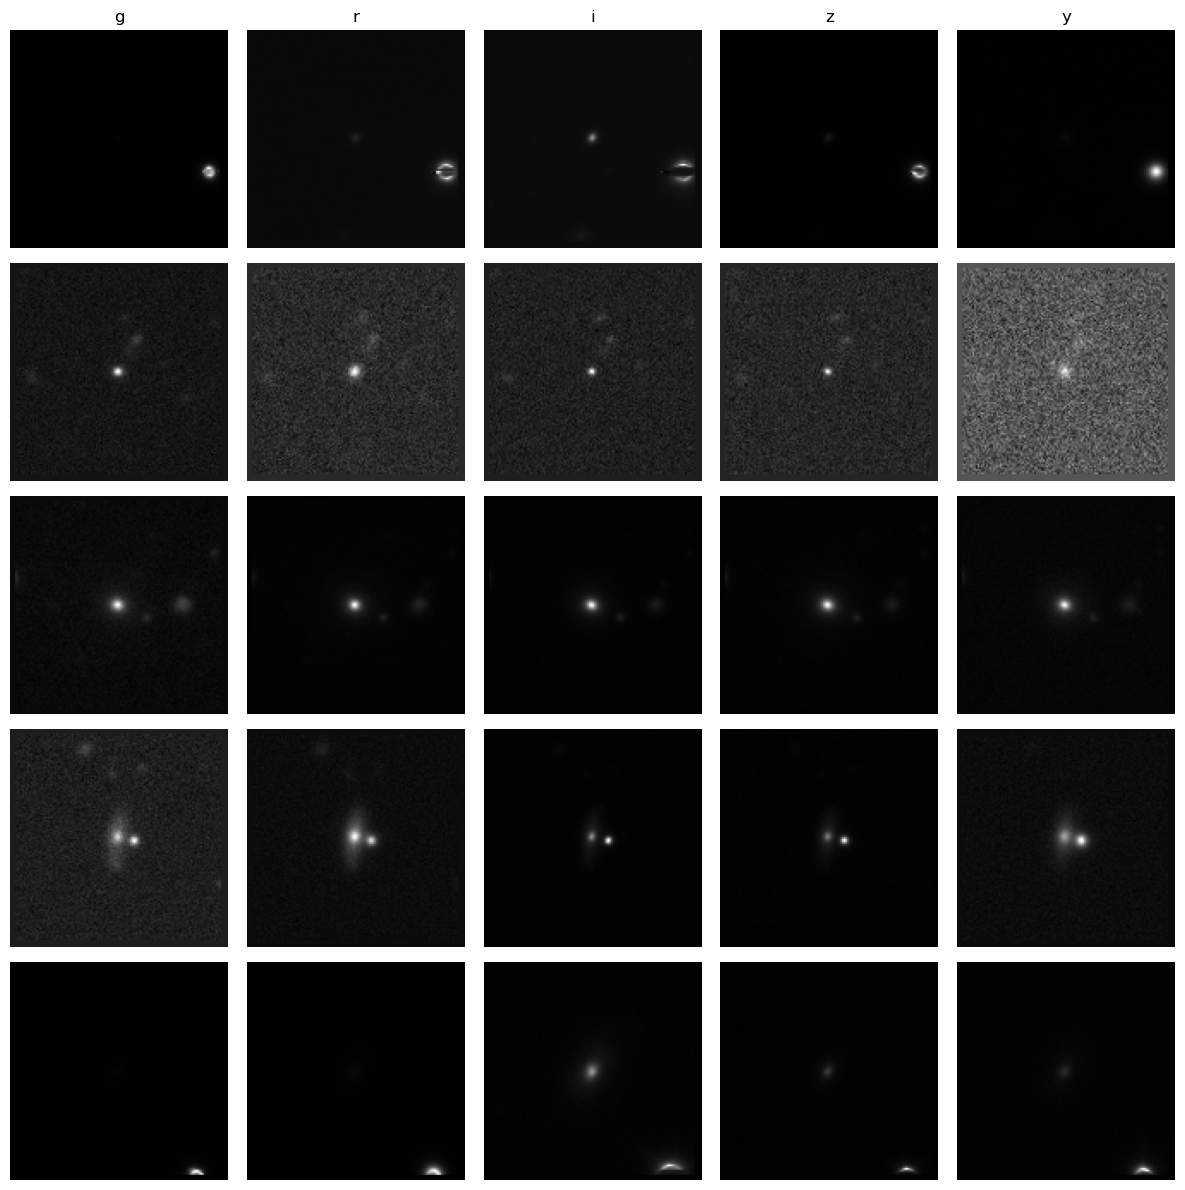

In [13]:
# Select five random galaxies from the 127x127 image dataset
# Only five galaxies are loaded into memory

with h5py.File(testing_127_path, "r") as f:
    idx_127 = sorted(
        random.sample(range(len(df_127)), 5)
    )
    
    images_127 = f["image"][idx_127]
# Display the five photometric bands for the selected galaxies

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row in range(5):
    for col in range(5):
        axes[row, col].imshow(
            images_127[row, col],
            cmap="gray"
        )
        
        axes[row, col].axis("off")
        
        if row == 0:
            axes[row, col].set_title(
                ["g", "r", "i", "z", "y"][col]
            )

plt.tight_layout()
plt.show()

In [16]:
# Select the same galaxy from both image resolutions

galaxy_index = 0

with h5py.File(file_path, "r") as f:
    galaxy_64 = f["image"][galaxy_index]

with h5py.File(testing_127_path, "r") as f:
    galaxy_127 = f["image"][galaxy_index]

print("64x64 shape:", galaxy_64.shape)
print("127x127 shape:", galaxy_127.shape)

64x64 shape: (5, 64, 64)
127x127 shape: (5, 127, 127)


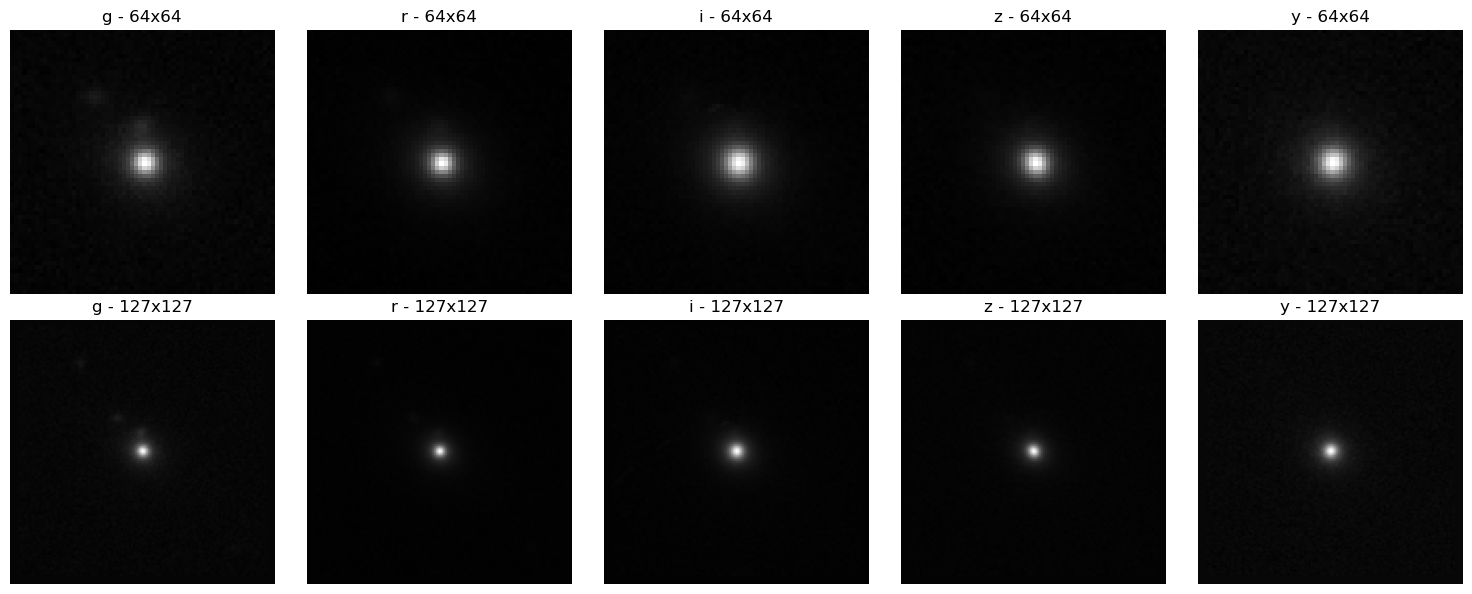

In [17]:
# Compare the same galaxy at 64x64 and 127x127 resolution

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

bands = ["g", "r", "i", "z", "y"]

for i in range(5):
    axes[0, i].imshow(galaxy_64[i], cmap="gray")
    axes[0, i].set_title(f"{bands[i]} - 64x64")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(galaxy_127[i], cmap="gray")
    axes[1, i].set_title(f"{bands[i]} - 127x127")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Calculate image statistics for the 127x127 dataset
# Images are processed in batches to avoid loading the entire file

num_127 = len(df_127)

band_stats_127 = {
    band: {
        "mean": [],
        "std": [],
        "min": [],
        "max": []
    }
    for band in bands
}

with h5py.File(testing_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_127, 500):
        end = min(start + 500, num_127)
        batch = images[start:end]

        for i, band in enumerate(bands):
            band_data = batch[:, i, :, :]

            band_stats_127[band]["mean"].append(
                np.mean(band_data, axis=(1, 2))
            )

            band_stats_127[band]["std"].append(
                np.std(band_data, axis=(1, 2))
            )

            band_stats_127[band]["min"].append(
                np.min(band_data, axis=(1, 2))
            )

            band_stats_127[band]["max"].append(
                np.max(band_data, axis=(1, 2))
            )
# Combine batch-level statistics for each band

image_stats_127 = {}

for band in bands:
    image_stats_127[band] = {
        key: np.concatenate(
            band_stats_127[band][key]
        )
        for key in band_stats_127[band]
    }

print("127x127 image statistics calculated successfully.")

127x127 image statistics calculated successfully.


g-band: 0.07661652
r-band: 0.15576287
i-band: 0.22949892
z-band: 0.30183715
y-band: 0.3667624


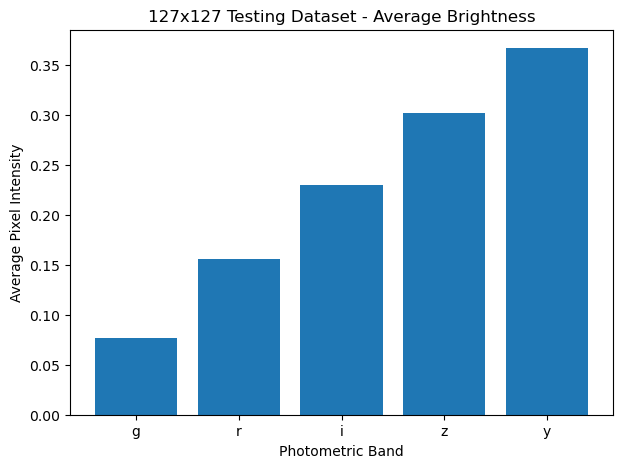

In [20]:
# Calculate average image brightness for each photometric band

mean_brightness_127 = [
    np.mean(image_stats_127[band]["mean"])
    for band in bands
]

for band, value in zip(bands, mean_brightness_127):
    print(f"{band}-band:", value)
# Compare average pixel brightness across the five bands

plt.figure(figsize=(7, 5))

plt.bar(bands, mean_brightness_127)

plt.xlabel("Photometric Band")
plt.ylabel("Average Pixel Intensity")
plt.title("127x127 Testing Dataset - Average Brightness")

plt.show()

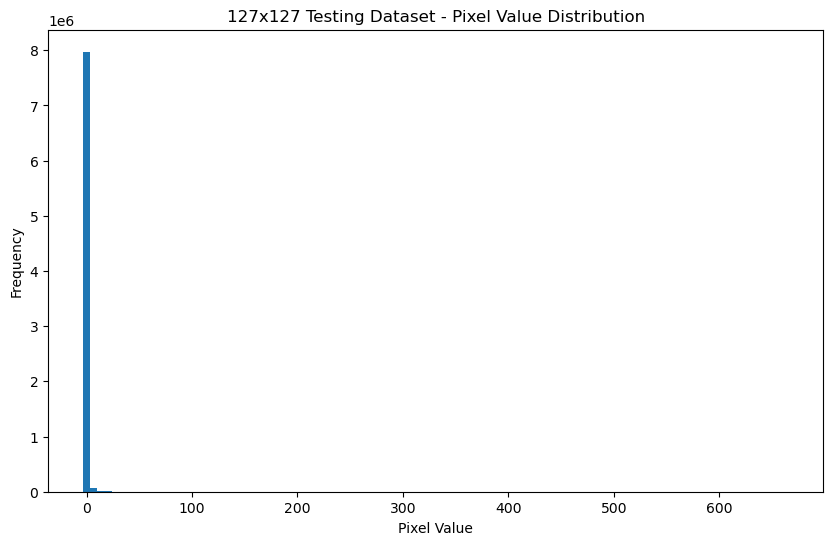

In [21]:
# Load a small sample of 100 galaxies to examine pixel-value distribution

with h5py.File(testing_127_path, "r") as f:
    sample_127 = f["image"][:100]
# Plot the distribution of pixel values

plt.figure(figsize=(10, 6))

plt.hist(
    sample_127.flatten(),
    bins=100
)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("127x127 Testing Dataset - Pixel Value Distribution")

plt.show()

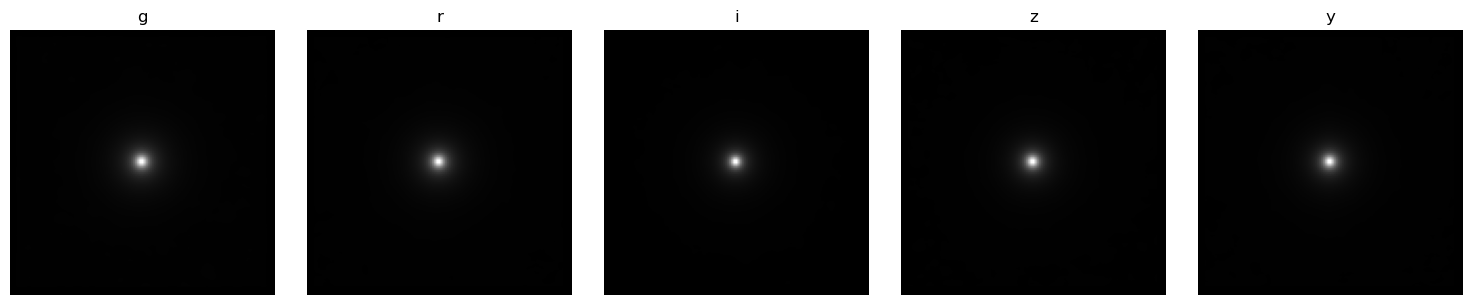

In [22]:
# Calculate the average 127x127 image for each photometric band
# Images are processed in batches to reduce memory usage

mean_band_127 = np.zeros((5, 127, 127))

with h5py.File(testing_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_127, 500):
        end = min(start + 500, num_127)

        batch = images[start:end]

        mean_band_127 += batch.sum(axis=0)

mean_band_127 /= num_127
# Display the average galaxy image for each photometric band

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, band in enumerate(bands):
    axes[i].imshow(
        mean_band_127[i],
        cmap="gray"
    )

    axes[i].set_title(band)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Calculate average image for each band in the 64x64 dataset

bands = ["g", "r", "i", "z", "y"]

with h5py.File(file_path, "r") as f:
    images = f["image"]
    num_64 = images.shape[0]

    mean_band = np.zeros((5, 64, 64), dtype=np.float64)

    for start in range(0, num_64, 500):
        end = min(start + 500, num_64)
        batch = images[start:end]

        mean_band += batch.sum(axis=0)

mean_band /= num_64

print("Number of 64x64 galaxies:", num_64)
print("Mean image shape:", mean_band.shape)

Number of 64x64 galaxies: 40914
Mean image shape: (5, 64, 64)


In [25]:
# Calculate average image for each band in the 127x127 dataset

num_127 = len(df_127)

mean_band_127 = np.zeros((5, 127, 127), dtype=np.float64)

with h5py.File(testing_127_path, "r") as f:
    images = f["image"]

    for start in range(0, num_127, 500):
        end = min(start + 500, num_127)
        batch = images[start:end]

        mean_band_127 += batch.sum(axis=0)

mean_band_127 /= num_127

print("127x127 mean image shape:", mean_band_127.shape)

127x127 mean image shape: (5, 127, 127)


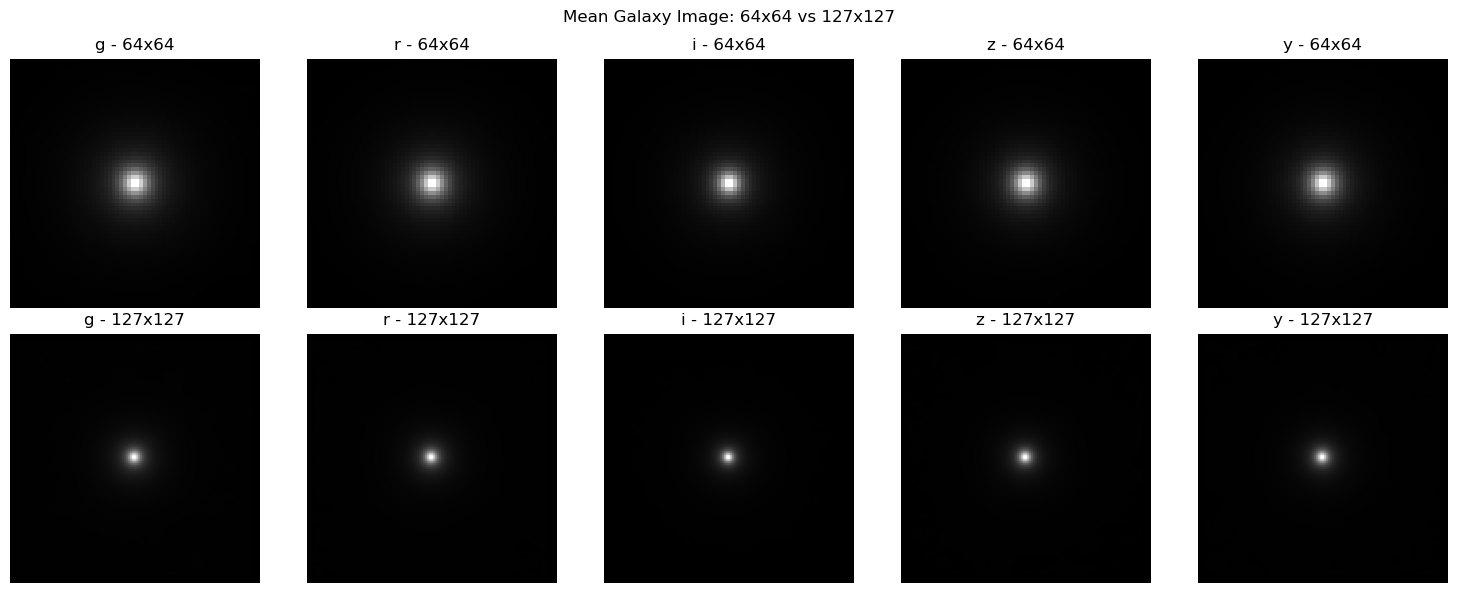

In [27]:
# Display mean images for 64x64 and 127x127

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, band in enumerate(bands):
    axes[0, i].imshow(mean_band[i], cmap="gray")
    axes[0, i].set_title(f"{band} - 64x64")
    axes[0, i].axis("off")

    axes[1, i].imshow(mean_band_127[i], cmap="gray")
    axes[1, i].set_title(f"{band} - 127x127")
    axes[1, i].axis("off")

plt.suptitle("Mean Galaxy Image: 64x64 vs 127x127")
plt.tight_layout()
plt.show()

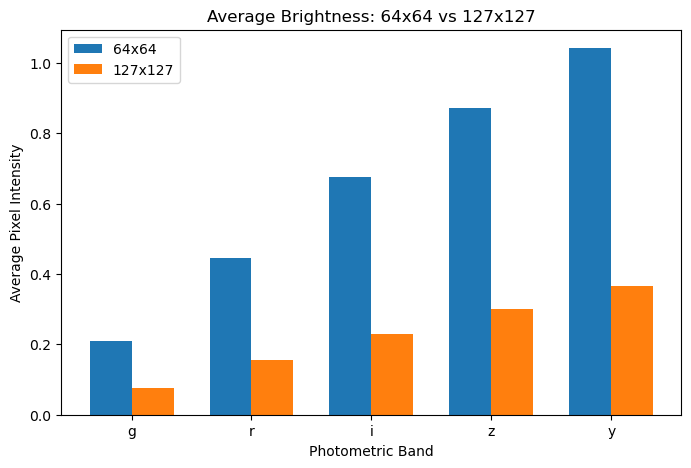

In [28]:
# Compare average pixel intensity between resolutions

mean_brightness_64 = [np.mean(mean_band[i]) for i in range(5)]
mean_brightness_127 = [np.mean(mean_band_127[i]) for i in range(5)]

x = np.arange(5)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, mean_brightness_64, width, label="64x64")
plt.bar(x + width/2, mean_brightness_127, width, label="127x127")

plt.xticks(x, bands)
plt.xlabel("Photometric Band")
plt.ylabel("Average Pixel Intensity")
plt.title("Average Brightness: 64x64 vs 127x127")
plt.legend()
plt.show()